In [2]:
import pandas as pd
import numpy as np
csv_path = 'ova_lung.csv'

In [3]:
df = pd.read_csv(csv_path)

In [4]:
df.isnull().values.any()

np.False_

In [5]:
X = df.drop(columns=['Tissue'])
skew_values = X.skew()
kurt_values = X.kurt()

In [58]:
X.shape

(1545, 10935)

In [6]:
print(skew_values.describe())
print(kurt_values.describe())

count    10935.000000
mean         4.124343
std          4.631818
min         -0.003285
25%          1.633869
50%          2.580549
75%          4.669467
max         39.193637
dtype: float64
count    10935.000000
mean        53.910506
std        142.596004
min         -0.854586
25%          5.198537
50%         12.575328
75%         38.093884
max       1538.997507
dtype: float64


In [7]:
import matplotlib.pyplot as plt

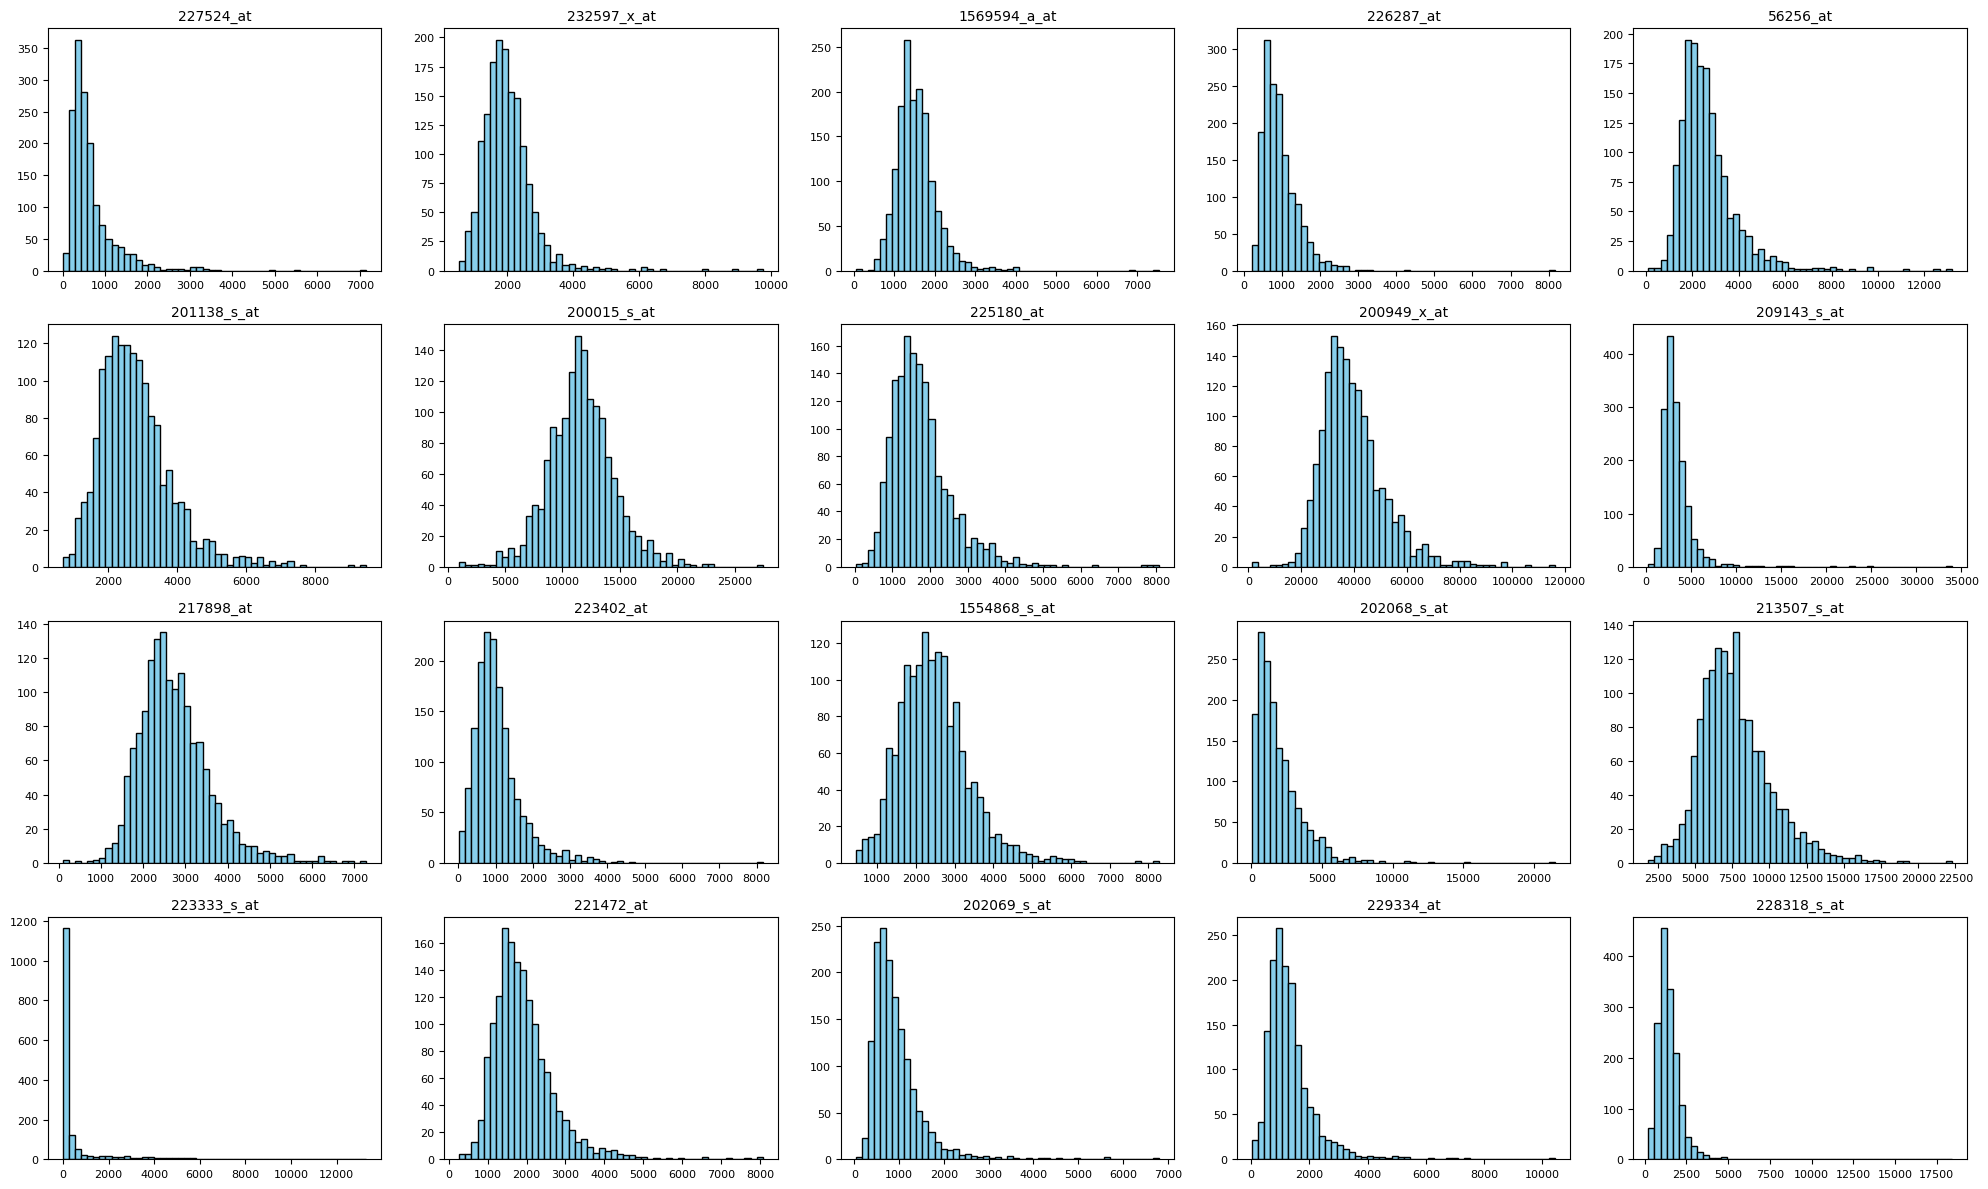

In [8]:
import random 

random_cols = random.sample(list(X.columns), 20)
n_rows = 4
n_cols = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))

axes = axes.flatten()

for i, col in enumerate(random_cols):
    axes[i].hist(X[col], bins=50, color='skyblue', edgecolor='black')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

In [9]:
y = df['Tissue'].map({'Other' : 0, 'Lung' : 1}).values

In [10]:
from sklearn.preprocessing import PowerTransformer

X_for_vis = X.copy()
pt = PowerTransformer(method='yeo-johnson')
X_transformed_vis = pt.fit_transform(X_for_vis)

In [11]:
X_transformed_vis_df = pd.DataFrame(
    X_transformed_vis,
    columns=X_for_vis.columns,
    index=X_for_vis.index
)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_vis_scaled = scaler.fit_transform(X_transformed_vis)

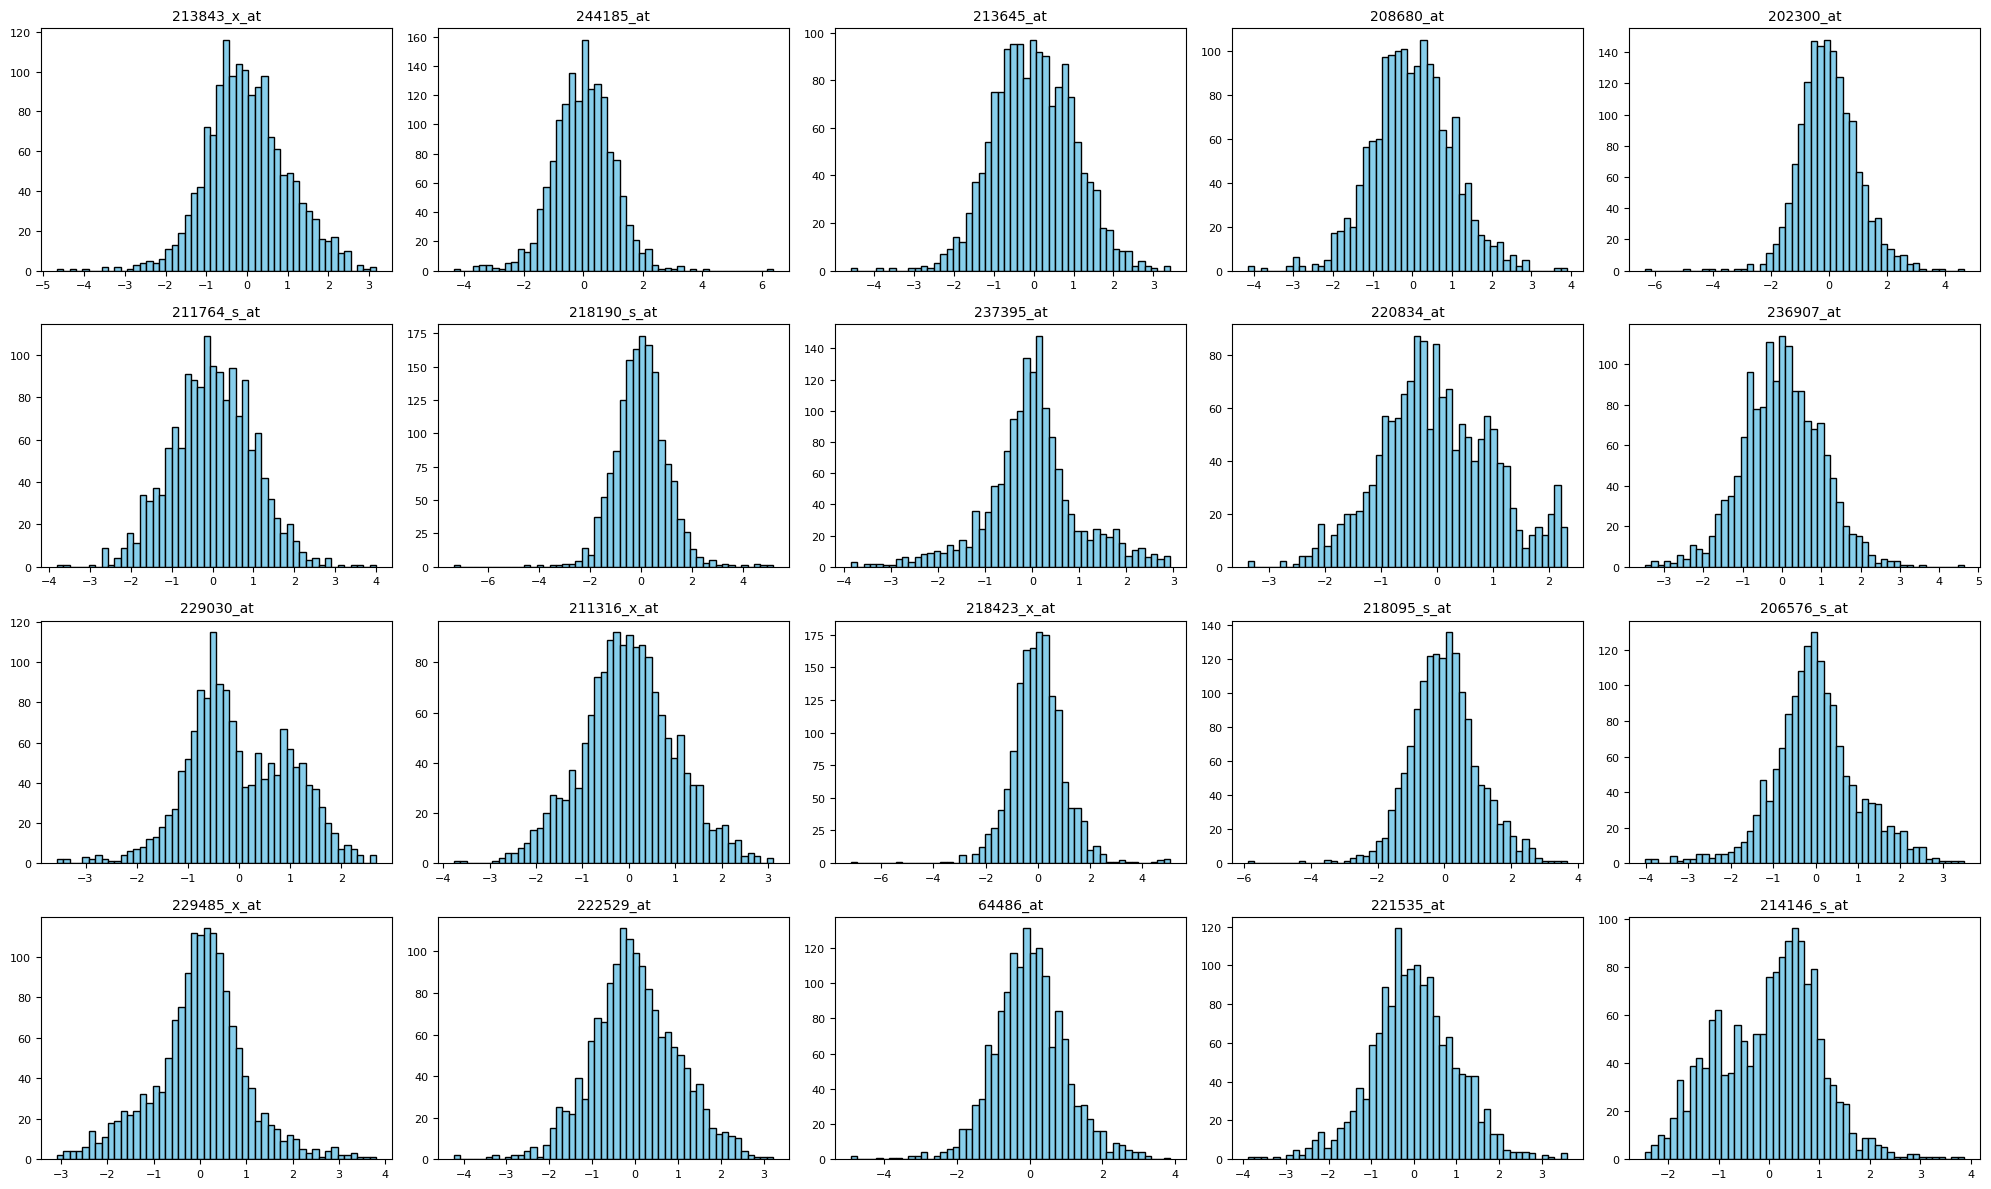

In [13]:


random_cols = random.sample(list(X_transformed_vis_df.columns), 20)

n_rows = 4
n_cols = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))

axes = axes.flatten()

for i, col in enumerate(random_cols):
    axes[i].hist(X_transformed_vis_df[col], bins=50, color='skyblue', edgecolor='black')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_vis_pca = pca.fit_transform(X_vis_scaled)

In [15]:
print("Pocetni atributi:", X_transformed_vis.shape[1])
print("Redukovani atributi:", X_vis_pca.shape[1])

Pocetni atributi: 10935
Redukovani atributi: 879


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, class_weight='balanced'),
    "SVM (Linear)": SVC(kernel='linear', probability=True, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42)
}

pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ('yeo', PowerTransformer(method='yeo-johnson')),
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('clf', model)
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'f1', 'recall']

results = []

for name, pipeline in pipelines.items():
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring)
    results.append({
        "Model": name,
        "Mean ROC-AUC": scores['test_roc_auc'].mean(),
        "Mean F1": scores['test_f1'].mean(),
        "Mean Recall": scores['test_recall'].mean()
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Mean ROC-AUC   Mean F1  Mean Recall
0  Logistic Regression      0.962989  0.909640     0.874769
1         SVM (Linear)      0.962367  0.895395     0.851077
2        Random Forest      0.958846  0.184423     0.103077
3                  KNN      0.933217  0.836827     0.755692
4    Gradient Boosting      0.952016  0.687152     0.549231


In [16]:
#Radi lakse reprodukcije i vizuelizacije u daljem kodu necu koristiti cross-validation vec samo train-test split

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train_trans = pt.fit_transform(X_train)
X_test_trans = pt.transform(X_test)

In [43]:
selector = VarianceThreshold(threshold=1.0)
X_train_var = selector.fit_transform(X_train_trans) 
X_test_var = selector.transform(X_test_trans)

X_train_scaled = scaler.fit_transform(X_train_trans)
X_test_scaled = scaler.transform(X_test_trans)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

selector = SelectKBest(f_classif, k=800)

X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel = selector.transform(X_test_scaled)

In [44]:
print("PCA broj atributa:", X_train_pca.shape[1])
print("SelectKBest broj atributa:", X_train_sel.shape[1])
print("VarianceThreshold broj atributa:", X_train_var.shape[1])
print("Originalni broj atributa:", X_train_scaled.shape[1])

PCA broj atributa: 733
SelectKBest broj atributa: 800
VarianceThreshold broj atributa: 1988
Originalni broj atributa: 10935


In [50]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, roc_auc_score, f1_score, recall_score

datasets = {
    "PCA": (X_train_pca, X_test_pca),
    "SelectKBest": (X_train_sel, X_test_sel),
    "VarianceThreshold": (X_train_var, X_test_var)
}

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, class_weight='balanced'),
    "SVM (Linear)": SVC(kernel='linear', probability=True, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, max_depth=None),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42)
}

In [45]:
def train_models(X_train, y_train, models):
    trained_models = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        trained_models[name] = model
    return trained_models

In [46]:
def plot_roc(trained_models, X_test, y_test, dataset_name):
    n_rows, n_cols = 2, 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 8))
    axes = axes.flatten()
    
    for i, (name, model) in enumerate(trained_models.items()):
        RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=axes[i])
        axes[i].plot([0,1],[0,1],'k--')
        axes[i].set_title(name)
    
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    
    plt.suptitle(f"ROC krive - {dataset_name}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [47]:
def plot_confusion(trained_models, X_test, y_test, dataset_name):
    n_rows, n_cols = 2, 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 8))
    axes = axes.flatten()
    
    for i, (name, model) in enumerate(trained_models.items()):
        ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=axes[i], display_labels=["Other","Lung"])
        axes[i].set_title(name)
    
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    
    plt.suptitle(f"Matrice konfuzije - {dataset_name}", fontsize=16)
    plt.tight_layout()
    plt.show()


In [48]:
def print_metrics(trained_models, X_test, y_test):
    for name, model in trained_models.items():
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:,1]
        else:
            y_prob = model.decision_function(X_test)
        y_pred = model.predict(X_test)
        print(f"{name}: ROC-AUC={roc_auc_score(y_test, y_prob):.3f}, F1={f1_score(y_test, y_pred):.3f}, Recall={recall_score(y_test, y_pred):.3f}")


--- Rezultati za PCA ---


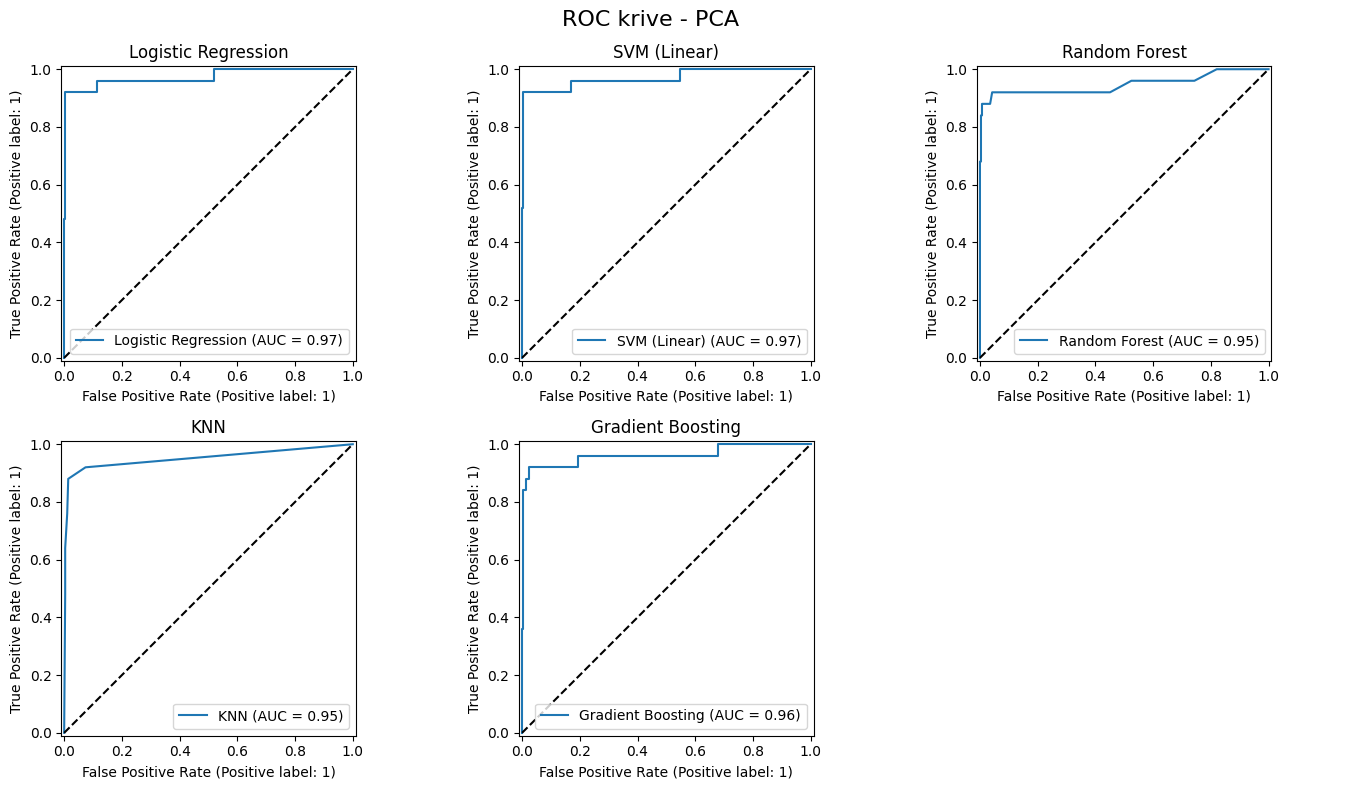

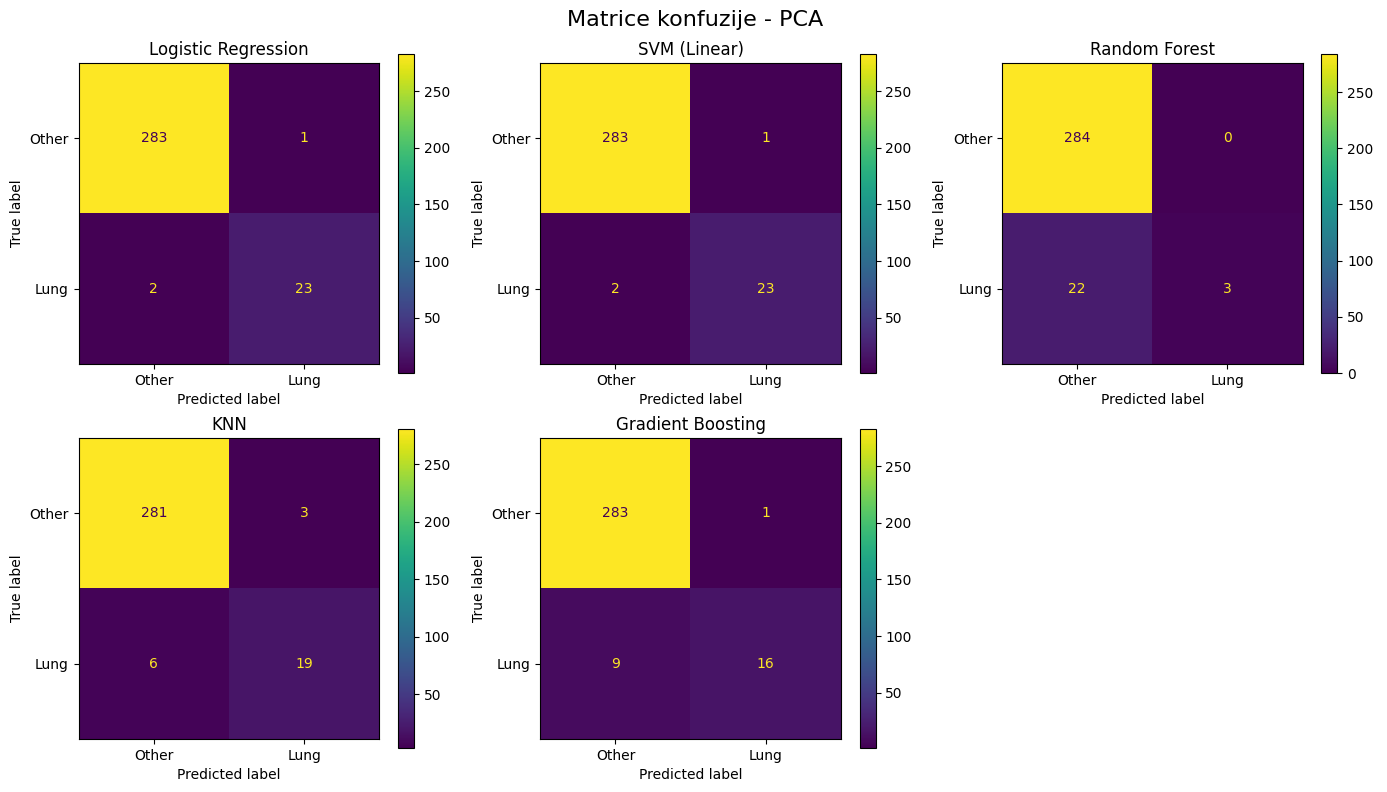

Logistic Regression: ROC-AUC=0.973, F1=0.939, Recall=0.920
SVM (Linear): ROC-AUC=0.970, F1=0.939, Recall=0.920
Random Forest: ROC-AUC=0.947, F1=0.214, Recall=0.120
KNN: ROC-AUC=0.952, F1=0.809, Recall=0.760
Gradient Boosting: ROC-AUC=0.962, F1=0.762, Recall=0.640

--- Rezultati za SelectKBest ---


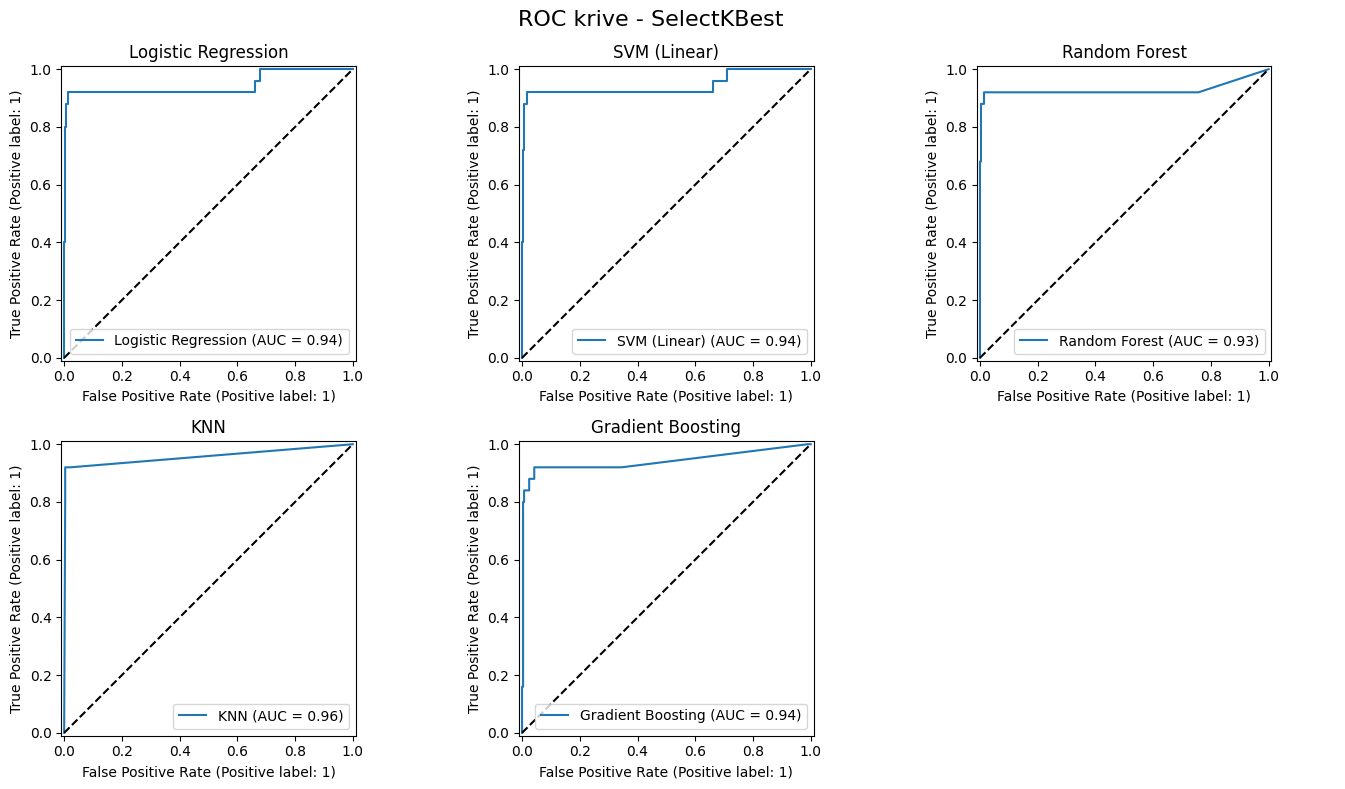

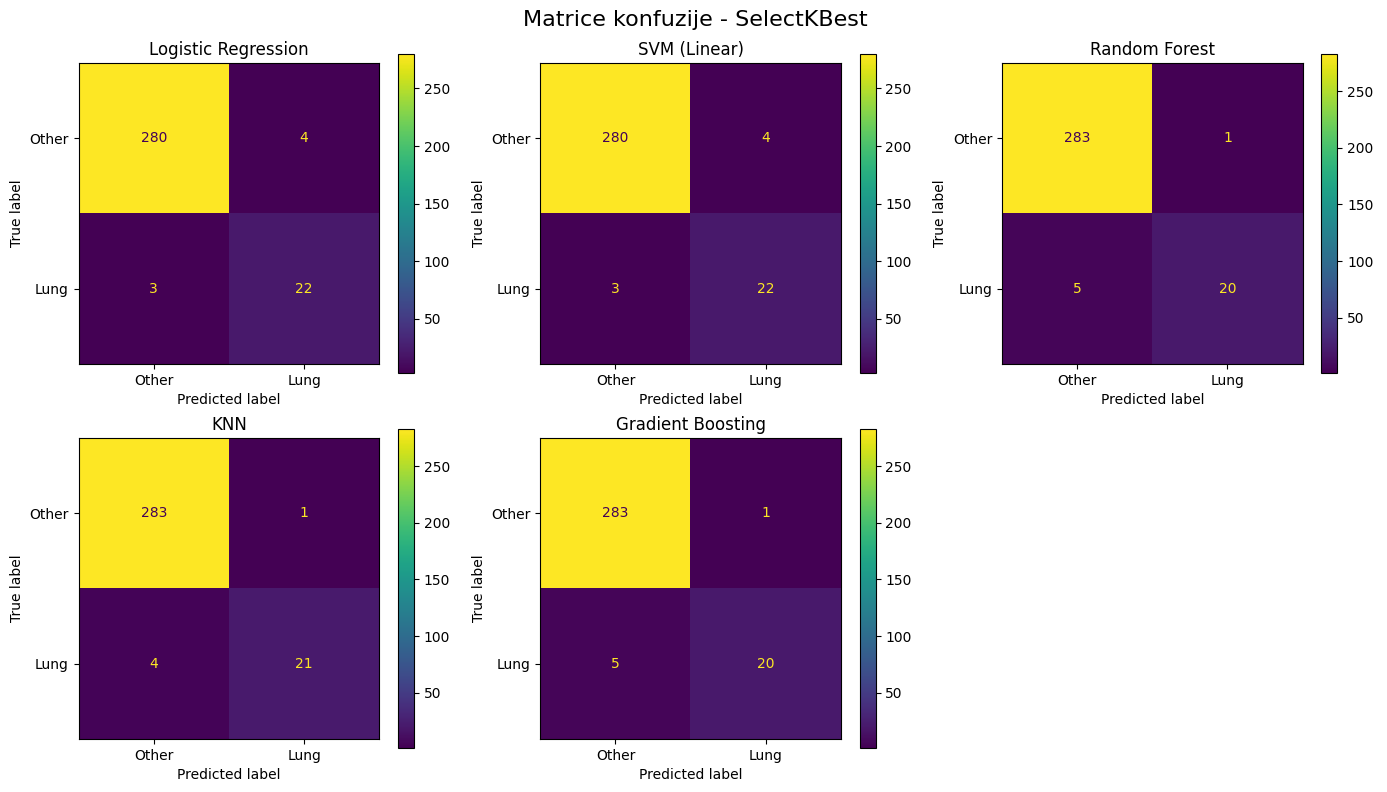

Logistic Regression: ROC-AUC=0.944, F1=0.863, Recall=0.880
SVM (Linear): ROC-AUC=0.942, F1=0.863, Recall=0.880
Random Forest: ROC-AUC=0.928, F1=0.870, Recall=0.800
KNN: ROC-AUC=0.957, F1=0.894, Recall=0.840
Gradient Boosting: ROC-AUC=0.941, F1=0.870, Recall=0.800

--- Rezultati za VarianceThreshold ---


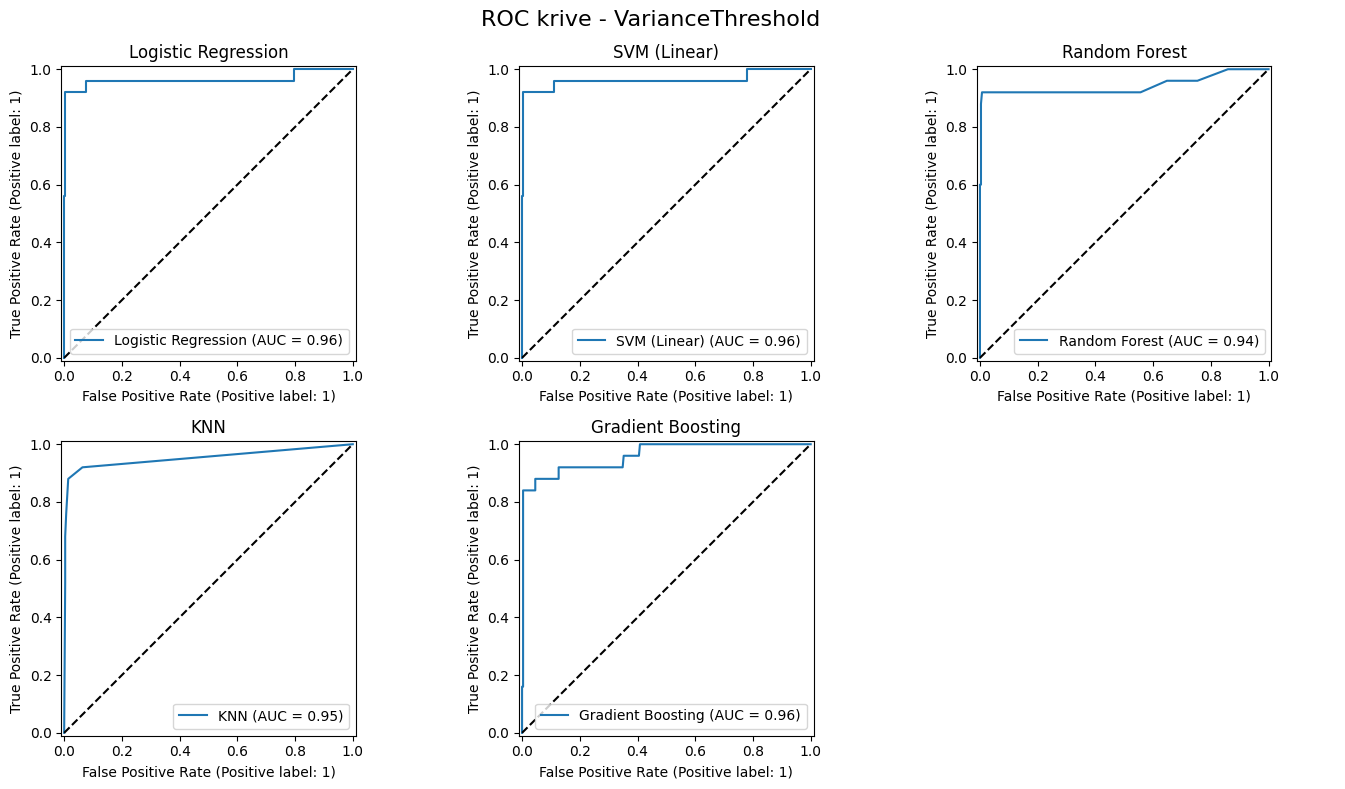

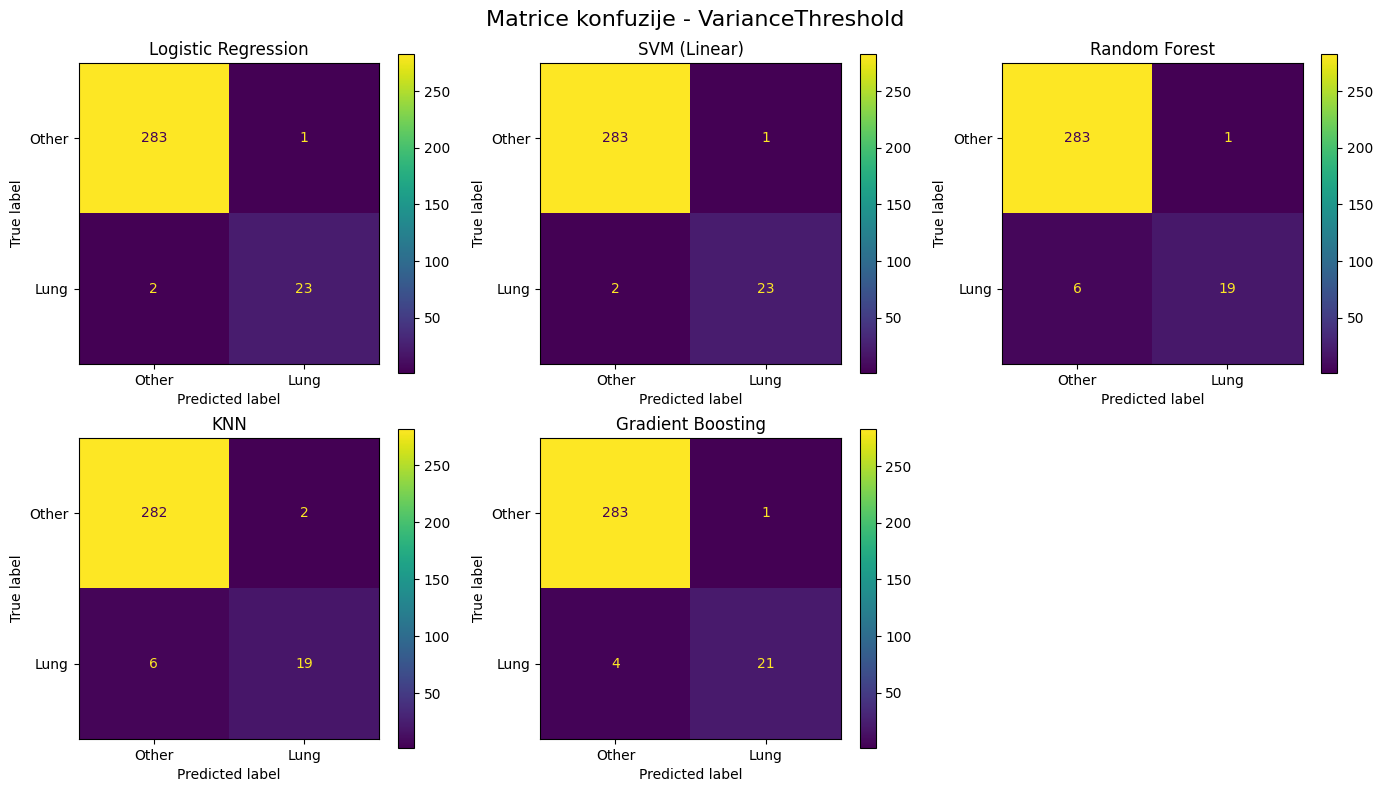

Logistic Regression: ROC-AUC=0.964, F1=0.939, Recall=0.920
SVM (Linear): ROC-AUC=0.963, F1=0.939, Recall=0.920
Random Forest: ROC-AUC=0.942, F1=0.844, Recall=0.760
KNN: ROC-AUC=0.953, F1=0.826, Recall=0.760
Gradient Boosting: ROC-AUC=0.960, F1=0.894, Recall=0.840


In [51]:
for ds_name, (X_tr, X_te) in datasets.items():
    print(f"\n--- Rezultati za {ds_name} ---")
    
    trained_models = train_models(X_tr, y_train, models)
    plot_roc(trained_models, X_te, y_test, ds_name)
    plot_confusion(trained_models, X_te, y_test, ds_name)
    print_metrics(trained_models, X_te, y_test)

In [52]:
summary = {
    "Method": [],
    "Model": [],
    "ROC-AUC": [],
    "F1": [],
    "Recall": []
}

methods = ["PCA", "SelectKBest", "VarianceThreshold"]
results = [
    
    [(0.973, 0.939, 0.920), (0.970, 0.939, 0.920), (0.947, 0.214, 0.120), (0.952, 0.809, 0.760), (0.962, 0.762, 0.640)],
    
    [(0.944, 0.863, 0.880), (0.942, 0.863, 0.880), (0.928, 0.870, 0.800), (0.957, 0.894, 0.840), (0.941, 0.870, 0.800)],

    [(0.964, 0.939, 0.920), (0.963, 0.939, 0.920), (0.942, 0.844, 0.760), (0.953, 0.826, 0.760), (0.960, 0.894, 0.840)]
]

model_names = ["Logistic Regression", "SVM (Linear)", "Random Forest", "KNN", "Gradient Boosting"]

for method, method_results in zip(methods, results):
    for model_name, (roc, f1, recall) in zip(model_names, method_results):
        summary["Method"].append(method)
        summary["Model"].append(model_name)
        summary["ROC-AUC"].append(roc)
        summary["F1"].append(f1)
        summary["Recall"].append(recall)

summary_df = pd.DataFrame(summary)

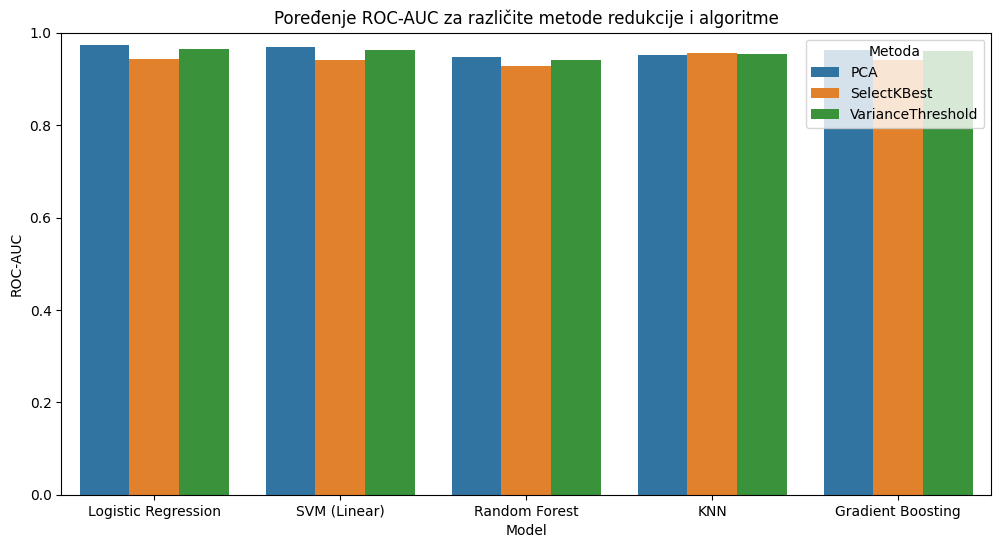

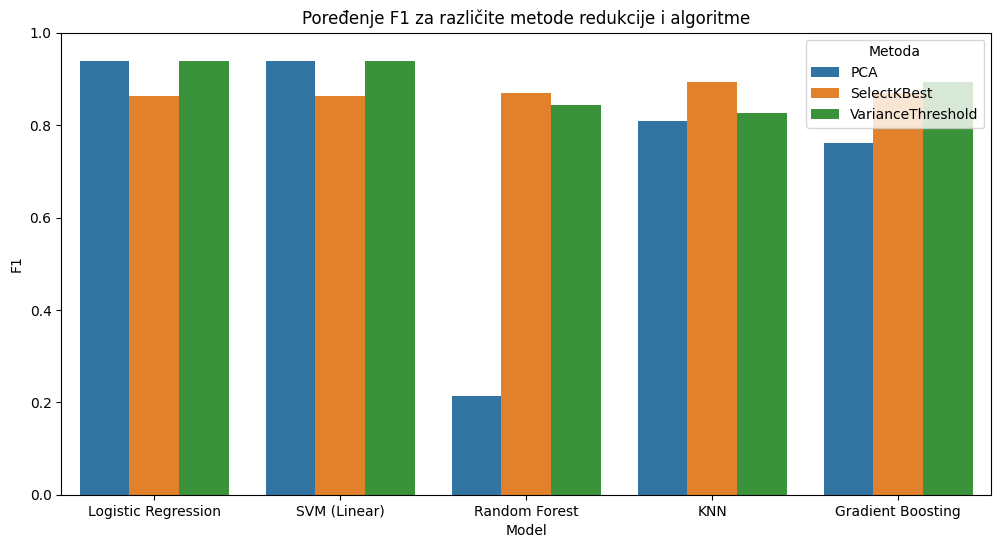

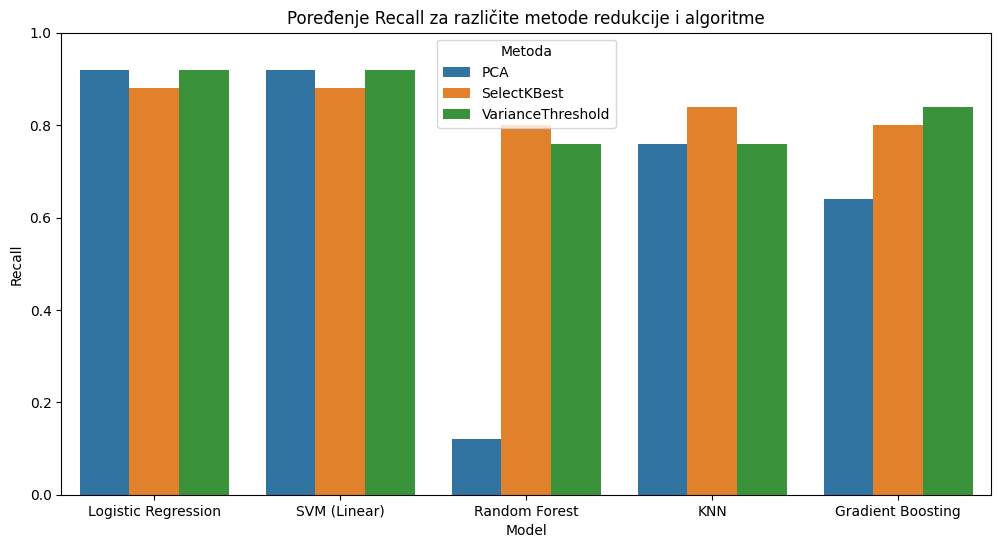

In [57]:
import seaborn as sns

metrics = ["ROC-AUC", "F1", "Recall"]

for metric in metrics:
    plt.figure(figsize=(12,6))
    sns.barplot(x="Model", y=metric, hue="Method", data=summary_df)
    plt.title(f"Poređenje {metric} za različite metode redukcije i algoritme")
    plt.ylim(0,1)
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.legend(title="Metoda")
    plt.show()